In [1]:
import pandas as pd

df = pd.read_excel ("Medallas_olímpicas.xlsx")

In [3]:
import os
from langchain.chat_models import init_chat_model
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

D:\Usuarios\SP44812227\AppData\Local\Temp\ipykernel_27084\2195057198.py:3: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent


In [4]:
with open("api_key.txt") as archivo:
    apikey = archivo.read().strip()
os.environ["OPENAI_API_KEY"] = apikey

# Inicializar el modelo
model = init_chat_model("gpt-4o-mini", model_provider="openai")

In [4]:
contexto_data = """
Eres un asistente experto en análisis de datos. 
Estás trabajando con un DataFrame llamado 'df' que contiene información sobre las medallas obtenidas en los Juegos Olímpicos.

Descripción de las columnas:
- 'País': Nombre de la nación participante.
- 'Oro': Cantidad de medallas de oro ganadas.
- 'Plata': Cantidad de medallas de plata ganadas.
- 'Bronce': Cantidad de medallas de bronce ganadas.
- 'Total': Suma total de medallas obtenidas por el país.
"""

In [ ]:
agent = create_pandas_dataframe_agent(
    model,
    df,
    verbose=True,
    allow_dangerous_code=True,
    agent_type="tool-calling", ##agregar esta linea
    prefix=contexto_data
)



In [9]:
# Ejemplo de consulta
query = "¿Cuáles es el país con mayor cantidad de medallas?"
respuesta = agent.run(query)

print(respuesta)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "max_medals = df.loc[df['Total'].idxmax()]\nmax_medals"}`


País       Estados Unidos (USA)
Oro                        1022
Plata                       794
Bronce                      704
Total                      2520
Name: 0, dtype: objectEl país con mayor cantidad de medallas es Estados Unidos (USA) con un total de 2520 medallas, desglosadas en 1022 medallas de oro, 794 de plata y 704 de bronce.

> Finished chain.
El país con mayor cantidad de medallas es Estados Unidos (USA) con un total de 2520 medallas, desglosadas en 1022 medallas de oro, 794 de plata y 704 de bronce.


In [10]:
df.loc[df['Total'].idxmax()]

País       Estados Unidos (USA)
Oro                        1022
Plata                       794
Bronce                      704
Total                      2520
Name: 0, dtype: object

In [11]:
query = "¿Cuáles son los 3 países con mayor medalla de Bronce?"
respuesta = agent.run(query)

print(respuesta)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df.nlargest(3, 'Bronce')[['País', 'Bronce']]"}`


                     País  Bronce
0    Estados Unidos (USA)     704
1   Unión Soviética (URS)     296
2       Reino Unido (GBR)     289Los 3 países con mayor cantidad de medallas de bronce son:

1. Estados Unidos (USA) - 704 medallas de bronce
2. Unión Soviética (URS) - 296 medallas de bronce
3. Reino Unido (GBR) - 289 medallas de bronce

> Finished chain.
Los 3 países con mayor cantidad de medallas de bronce son:

1. Estados Unidos (USA) - 704 medallas de bronce
2. Unión Soviética (URS) - 296 medallas de bronce
3. Reino Unido (GBR) - 289 medallas de bronce


In [12]:
df.nlargest(3, 'Bronce')[['País', 'Bronce']]

,País,Bronce
0,Estados Unidos (USA),704
1,Unión Soviética (URS),296
2,Reino Unido (GBR),289


graficas



> Entering new AgentExecutor chain...


<string>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



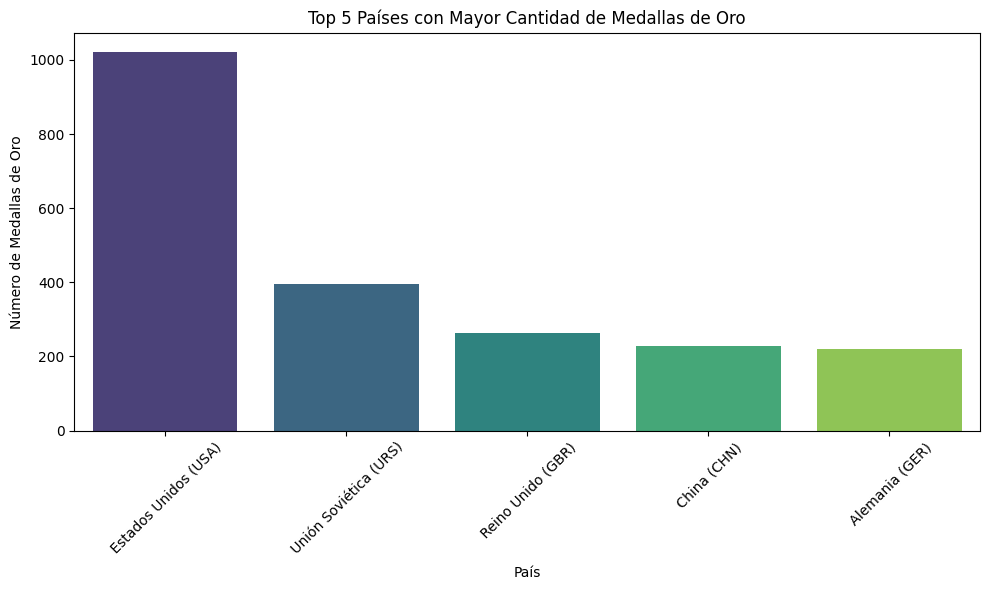


Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Supongamos que el DataFrame se llama df y ya está definido\n\n# Filtra los 5 países con la mayor cantidad de medallas de oro\ntop_oros = df.nlargest(5, 'Oro')\n\n# Crea el gráfico de barras\nplt.figure(figsize=(10, 6))\n# Usamos una paleta de colores agradable\nsns.barplot(x='País', y='Oro', data=top_oros, palette='viridis')\nplt.title('Top 5 Países con Mayor Cantidad de Medallas de Oro')\nplt.xlabel('País')\nplt.ylabel('Número de Medallas de Oro')\nplt.xticks(rotation=45)  # Gira las etiquetas del eje x para mejor legibilidad\nplt.tight_layout()  # Ajusta el diseño para que no se corten las etiquetas\nplt.show()"}`


He creado un gráfico de barras que muestra los 5 países con la mayor cantidad de medallas de oro. Puedes visualizarlo ahora.

> Finished chain.


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from langchain.chat_models import init_chat_model
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

# Configuración de la API Key
with open("api_key.txt") as archivo:
    apikey = archivo.read().strip()
os.environ["OPENAI_API_KEY"] = apikey

# Inicializar el modelo
model = init_chat_model("gpt-4o-mini", model_provider="openai")

# Configuración del contexto con instrucciones explícitas de graficado
contexto_instrucciones = """
Eres un asistente experto en análisis de datos. Estás trabajando con un DataFrame de Pandas llamado 'df' que contiene información sobre medallas olímpicas.

Descripción de las columnas:
- 'País': Nombre de la nación.
- 'Oro': Cantidad de medallas de oro.
- 'Plata': Cantidad de medallas de plata.
- 'Bronce': Cantidad de medallas de bronce.
- 'Total': Suma total de medallas.

REQUISITOS CRÍTICOS PARA GRÁFICOS:
1. Siempre que el usuario solicite un gráfico, debes generarlo utilizando la librería 'seaborn'.
2. Incluye obligatoriamente buenas prácticas de visualización: título descriptivo, etiquetas claras en los ejes 'x' e 'y', y una paleta de colores estéticamente agradable.
3. Al finalizar el código del gráfico, debes incluir SIEMPRE 'plt.show()' para asegurar que la imagen se renderice en la pantalla del usuario.
"""

# Inicializar el agente con el prefijo adaptado
agent = create_pandas_dataframe_agent(
    model,
    df,
    verbose=True,
    allow_dangerous_code=True,
    agent_type="tool-calling", #agregamos esta linea
    prefix=contexto_instrucciones,
    max_iterations=5,  # Limita el número máximo de llamadas a herramientas/consultas internas
    max_execution_time=10.0,  # Limita el tiempo total de ejecución en segundos (float)
)

# Consulta para graficar
query = "Crear un gráfico de barras con los 5 países y sus respectivas cantidades con la mayor cantidad de medallas oro"
respuesta = agent.run(query)

C:\Users\eparedes\AppData\Local\Temp\ipykernel_3048\4069449288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='País', y='Oro', data=top_oros, palette='viridis')


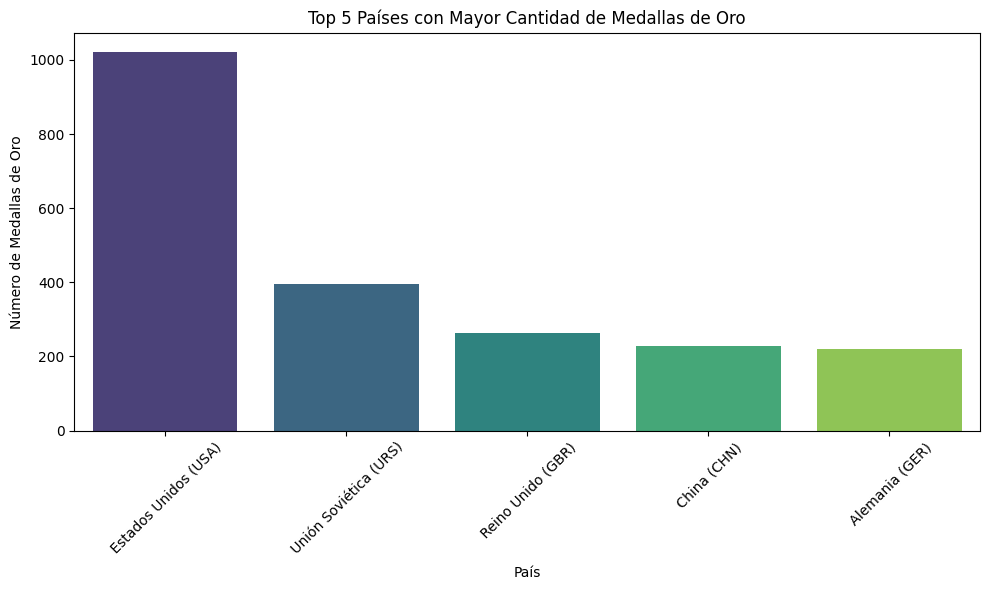

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Supongamos que el DataFrame se llama df y ya está definido
# # Filtra los 5 países con la mayor cantidad de medallas de oro\n
top_oros = df.nlargest(5, 'Oro')
# Crea el gráfico de barras\n
plt.figure(figsize=(10, 6))
# Usamos una paleta de colores agradable
sns.barplot(x='País', y='Oro', data=top_oros, palette='viridis')
plt.title('Top 5 Países con Mayor Cantidad de Medallas de Oro')
plt.xlabel('País')
plt.ylabel('Número de Medallas de Oro')
plt.xticks(rotation=45)  # Gira las etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajusta el diseño para que no se corten las etiquetas
plt.show()

In [ ]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agents.agent_toolkits import create_sql_agent